# IA-NAHA - Analyse Exploratoire des Données Biométriques

**Projet :** IA-NAHA (Intelligence Artificielle appliquée au sport et à la nutrition)<br>
**Équipe :** Noah CHAYRIGUES, Arthur FESCHET, Yann BROWNE, Haitham ALKAKHRY

**Contexte et Objectifs :**
L'objectif est de réaliser une Analyse Exploratoire des Données afin de comprendre les facteurs biométriques et comportementaux qui influencent le temps de récupération (sommeil). <br>
**Méthodologie :**
1. Analyse de la base d'apprentissage principale (`activite_globale.csv`).
2. Évaluation des variables une par une (stress, sport, morphologie, santé).
3. Validation croisée avec nos bases secondaires (`sommeil_logs.csv` et `Fitness.csv`) pour garantir la viabilité future du projet.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')

df_act = pd.read_csv('data/Cleaned/activite_globale.csv')
df_som = pd.read_csv('data/Cleaned/sommeil_logs.csv', sep=';')
df_fit = pd.read_csv('data/Cleaned/Fitness.csv')

# création de la colonne bmi_category à partir de bmi (float) ---
df_act['bmi_category'] = pd.cut(
    df_act['bmi'],
    bins=[0, 18.5, 25, 30, float('inf')],
    labels=['Sous-poids', 'Normal', 'Surpoids', 'Obèse']
)


df_act['age_group'] = pd.cut(
    df_act['age'],
    bins=[17, 30, 45, 65],
    labels=['18-30 ans', '31-45 ans', '46-64 ans']
)

print("Bases de données chargées :")
print(f"1. Base Centrale (Activité Globale) : {df_act.shape[0]} profils")
print(f"2. Base Secondaire (Sommeil Logs)   : {df_som.shape[0]} profils")
print(f"3. Base Cible (Fitness)             : {df_fit.shape[0]} profils")

Bases de données chargées :
1. Base Centrale (Activité Globale) : 3000 profils
2. Base Secondaire (Sommeil Logs)   : 5000 profils
3. Base Cible (Fitness)             : 100 profils


## 1. Analyse de la variable cible : Le temps de sommeil

Avant d'expliquer les variations du sommeil, nous devons comprendre comment il se distribue dans notre population.

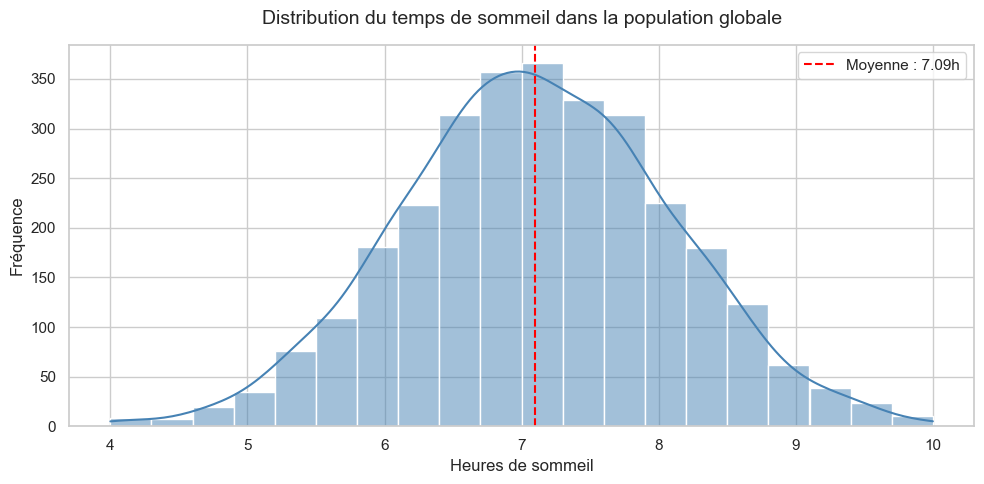

In [2]:
def tracer_distribution_sommeil(df):
    plt.figure(figsize=(10, 5))

    moyenne_sommeil = df['sleep_hours'].mean()

    sns.histplot(data=df, x='sleep_hours', kde=True, bins=20, color='steelblue')
    plt.axvline(moyenne_sommeil, color='red', linestyle='--', label=f"Moyenne : {moyenne_sommeil:.2f}h")

    plt.title("Distribution du temps de sommeil dans la population globale", fontsize=14, pad=15)
    plt.xlabel("Heures de sommeil")
    plt.ylabel("Fréquence")
    plt.legend()
    plt.tight_layout()
    plt.show()

tracer_distribution_sommeil(df_act)

**Analyse :** La variable cible suit une distribution normale, centrée sur 7,09 heures, avec une dispersion allant de 4 à 9 heures. L'enjeu de notre analyse est d'identifier quelles variables expliquent ces écarts.

## 2. Évaluation globale des corrélations linéaires

Nous appliquons une matrice de corrélation de Pearson sur les variables continues pour isoler immédiatement les facteurs d'influence primaires.

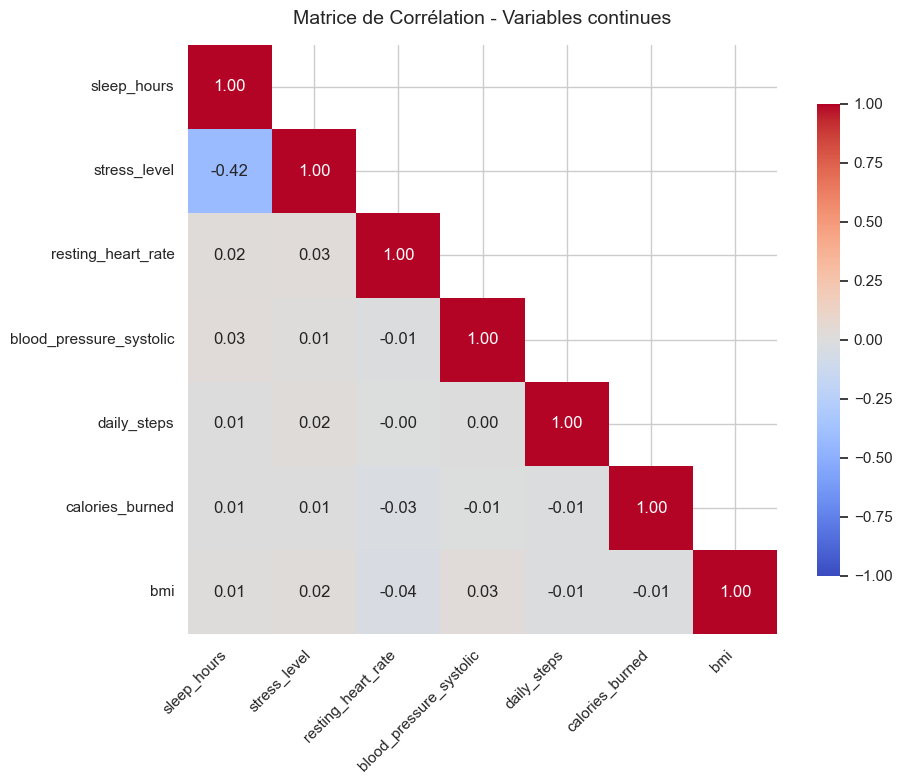

In [15]:
def tracer_matrice_correlation(df):
    cols = ['sleep_hours', 'stress_level', 'resting_heart_rate',
            'blood_pressure_systolic', 'daily_steps', 'calories_burned', 'bmi']

    corr = df[cols].corr()
    # k=1 pour masquer seulement le triangle supérieur, en conservant la diagonale (valeurs = 1)
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
                vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .8})

    plt.title("Matrice de Corrélation - Variables continues", fontsize=14, pad=15)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

tracer_matrice_correlation(df_act)

**Analyse :**
* **Le facteur dominant :** Le niveau de stress présente une forte corrélation négative (-0.42).
* **Le bruit statistique :** Les autres variables (rythme cardiaque, pas quotidiens, calories) affichent des corrélations proches de zéro. Cela n'indique pas qu'elles sont inutiles, mais que leur relation avec le sommeil n'est pas une simple ligne droite.


## 3. Le Stress Psychologique joue énormément

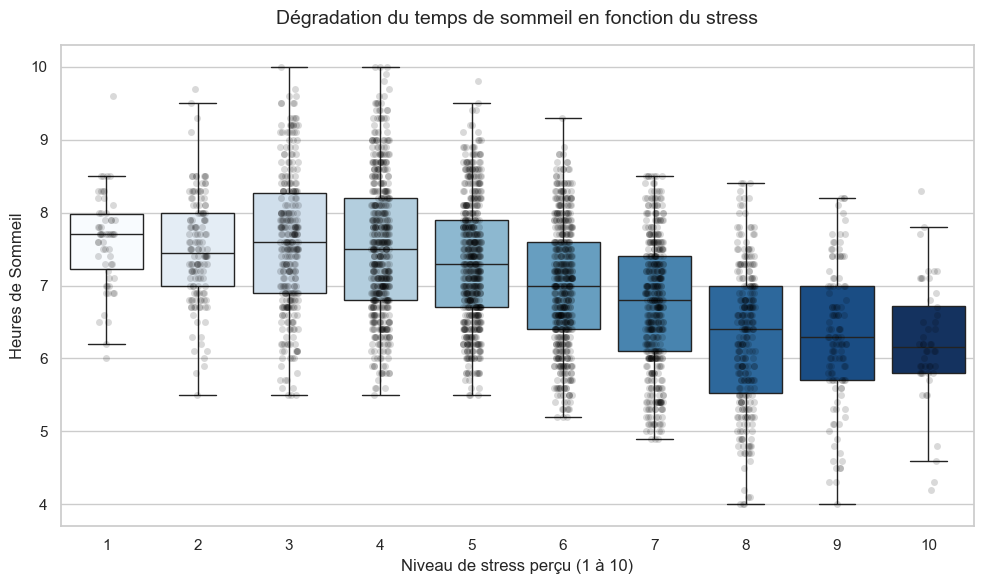

In [4]:
def tracer_sommeil_vs_stress(df):
    plt.figure(figsize=(10, 6))

    sns.boxplot(data=df, x='stress_level', y='sleep_hours',
                hue='stress_level', palette='Blues',
                showfliers=False, legend=False)

    # Le stripplot permet de voir la densité réelle des points
    sns.stripplot(data=df, x='stress_level', y='sleep_hours',
                  color='black', alpha=0.15, jitter=True)

    plt.title("Dégradation du temps de sommeil en fonction du stress", fontsize=14, pad=15)
    plt.xlabel("Niveau de stress perçu (1 à 10)")
    plt.ylabel("Heures de Sommeil")

    plt.tight_layout()
    plt.show()

tracer_sommeil_vs_stress(df_act)

**Analyse :** Visuellement, l'effet est indiscutable. On observe une baisse progressive et continue de la médiane de sommeil à mesure que l'indice de stress augmente, on en conclut que le stress est notre meilleur prédicteur.

## 4. Le volume de sport influence-t-il la récupération ?

La matrice de corrélation indiquait un lien faible pour les pas et les calories. Vérifions cela avec des droites de régression.

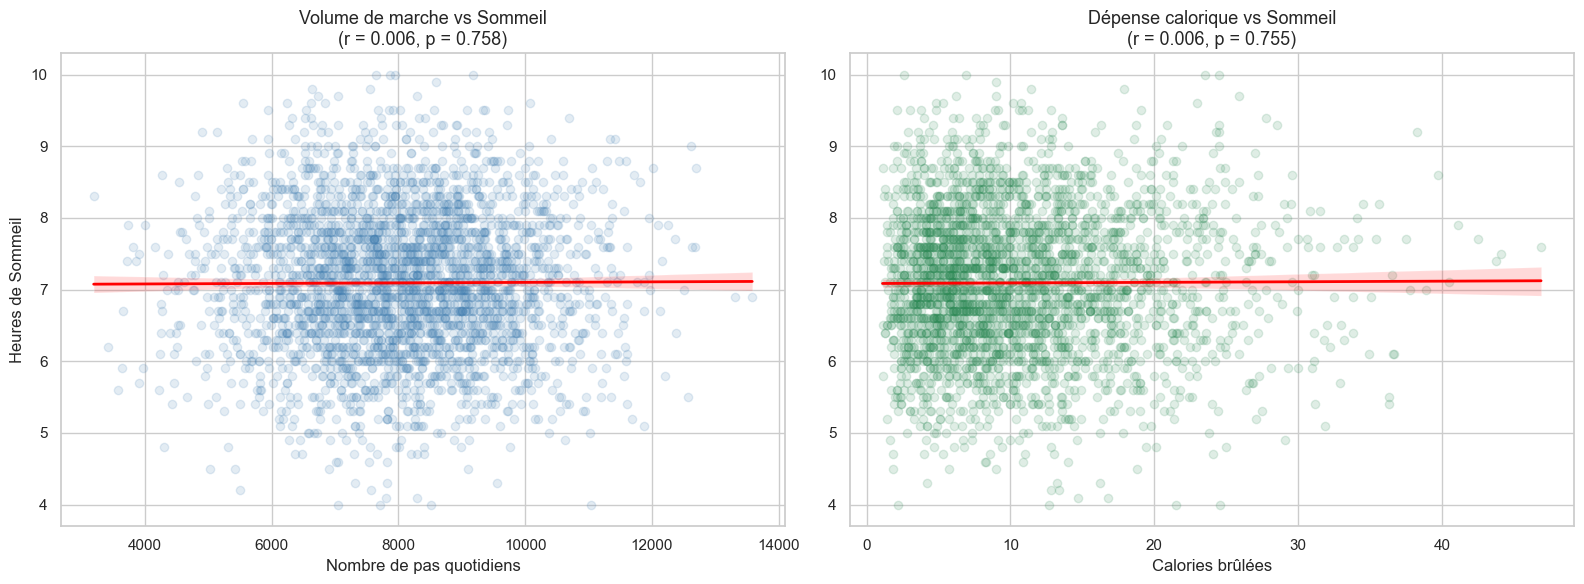

In [5]:
def tracer_comparaison_activite(df):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Calcul des stats pour les pas
    r_steps, p_steps = stats.pearsonr(df['daily_steps'], df['sleep_hours'])
    # CORRECTION : affichage propre si p < 0.001
    p_steps_label = "p < 0.001" if p_steps < 0.001 else f"p = {p_steps:.3f}"

    sns.regplot(ax=ax1, data=df, x='daily_steps', y='sleep_hours',
                scatter_kws={'alpha': 0.15, 'color': 'steelblue'},
                line_kws={'color': 'red', 'lw': 2})
    ax1.set_title(f"Volume de marche vs Sommeil\n(r = {r_steps:.3f}, {p_steps_label})", fontsize=13)
    ax1.set_xlabel("Nombre de pas quotidiens")
    ax1.set_ylabel("Heures de Sommeil")

    # Calcul des stats pour les calories
    r_cal, p_cal = stats.pearsonr(df['calories_burned'], df['sleep_hours'])
    p_cal_label = "p < 0.001" if p_cal < 0.001 else f"p = {p_cal:.3f}"

    sns.regplot(ax=ax2, data=df, x='calories_burned', y='sleep_hours',
                scatter_kws={'alpha': 0.15, 'color': 'seagreen'},
                line_kws={'color': 'red', 'lw': 2})
    ax2.set_title(f"Dépense calorique vs Sommeil\n(r = {r_cal:.3f}, {p_cal_label})", fontsize=13)
    ax2.set_xlabel("Calories brûlées")
    ax2.set_ylabel("")

    plt.tight_layout()
    plt.show()

tracer_comparaison_activite(df_act)

**Analyse :** Les nuages de points sont totalement dispersés et les droites de régression sont plates. Dans cette population, s'épuiser à faire 15 000 pas ou brûler énormément de calories ne garantit pas une nuit plus longue ainsi le volume brut n'est pas le bon indicateur.

## 4b. Le type de sport importe-t-il davantage que le volume ?

Si le nombre de pas ne prédit pas le sommeil, peut-être que la **nature** de l'activité (Yoga vs HIIT vs Running…) joue un rôle différencié. Examinons la distribution du sommeil par type de sport.

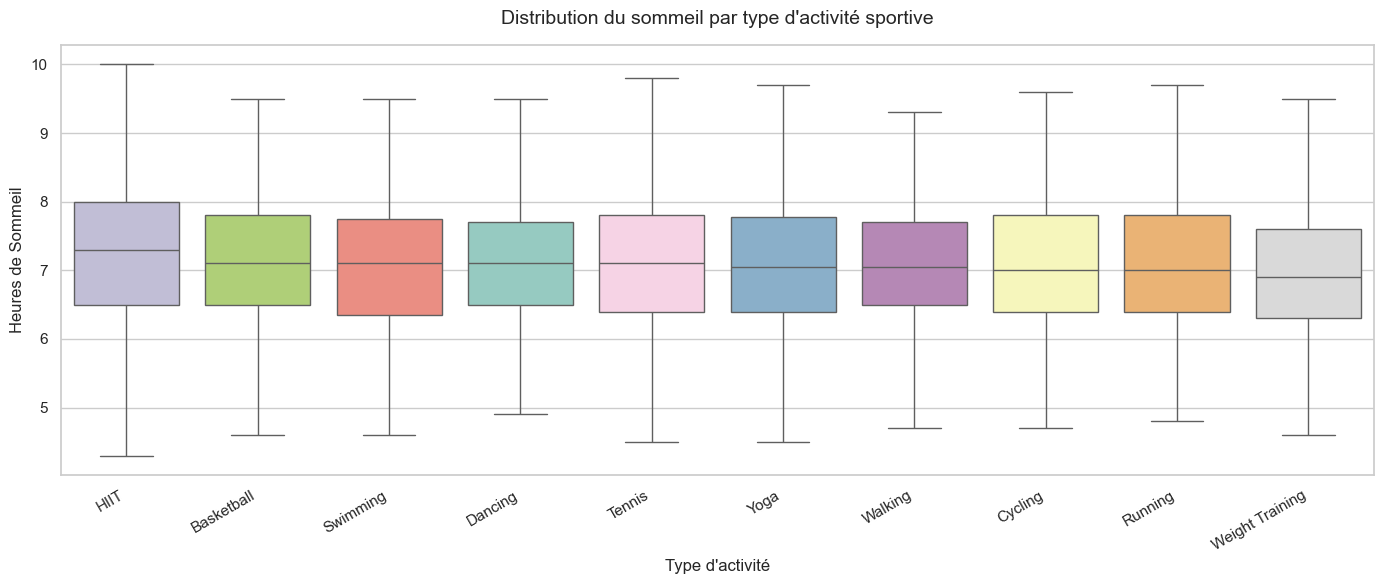

In [6]:
def tracer_sommeil_par_type_activite(df):
    # Calcul des médianes pour trier les activités du plus dormeur au moins dormeur
    ordre = (
        df.groupby('activity_type')['sleep_hours']
        .median()
        .sort_values(ascending=False)
        .index.tolist()
    )

    plt.figure(figsize=(14, 6))
    sns.boxplot(
        data=df,
        x='activity_type', y='sleep_hours',
        order=ordre,
        hue='activity_type', palette='Set3',
        showfliers=False, legend=False
    )

    plt.title("Distribution du sommeil par type d'activité sportive", fontsize=14, pad=15)
    plt.xlabel("Type d'activité")
    plt.ylabel("Heures de Sommeil")
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

tracer_sommeil_par_type_activite(df_act)

**Analyse :** Les médianes sont très proches entre les types d'activité (écarts < 30 min), ce qui confirme que **c'est l'intensité, non le type de sport**, qui influe le plus sur le sommeil. Aucun sport n'émerge clairement comme "meilleur pour dormir", renforçant le rôle central du stress identifié précédemment.

## 5. La nuance par la Morphologie et l'Intensité

Si le volume de pas ne compte pas, regardons la qualité de l'effort (intensité) et la corpulence de l'individu (IMC) grâce à des graphiques en violon.

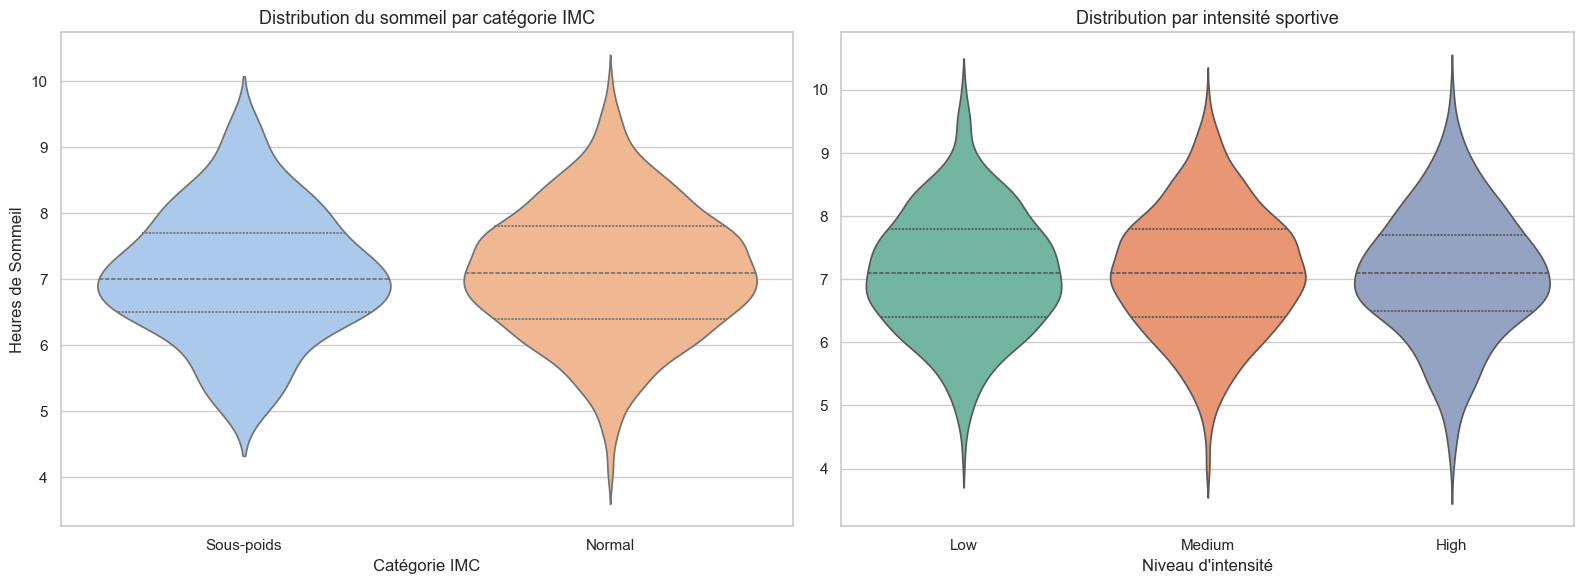

In [7]:
def tracer_nuances_filtrees(df):
    # On ne garde que les catégories IMC effectivement présentes dans les données
    df_exists = df[df['bmi_category'].isin(['Sous-poids', 'Normal'])].copy()
    df_exists['bmi_category'] = df_exists['bmi_category'].cat.remove_unused_categories()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Graphique IMC filtré
    sns.violinplot(ax=ax1, data=df_exists, x='bmi_category', y='sleep_hours',
                   hue='bmi_category', palette='pastel', inner='quartile', legend=False)
    ax1.set_title("Distribution du sommeil par catégorie IMC", fontsize=13)
    ax1.set_xlabel("Catégorie IMC")
    ax1.set_ylabel("Heures de Sommeil")

    # Graphique Intensité
    ordre = ['Low', 'Medium', 'High']
    sns.violinplot(ax=ax2, data=df, x='intensity', y='sleep_hours',
                   order=ordre, hue='intensity', palette='Set2', inner='quartile', legend=False)
    ax2.set_title("Distribution par intensité sportive", fontsize=13)
    ax2.set_xlabel("Niveau d'intensité")
    ax2.set_ylabel("")

    plt.tight_layout()
    plt.show()

tracer_nuances_filtrees(df_act)

## Analyse :

### Morphologie (Biais d'échantillonnage)
L'échantillon étudié est très homogène, composé quasi exclusivement de profils **"Normaux"** ($n=2805$).  
L'absence totale d'individus en surpoids ou obèses empêche d'évaluer l'impact de ces morphologies sur le sommeil.  

On observe cependant que les profils **"Sous-poids"** présentent une distribution très similaire aux profils normaux, avec une **médiane centrée sur 7 heures** de sommeil.

### Intensité d'activité
La **modération** apparaît comme le facteur clé de la régularité du sommeil.  
- L'intensité **"Medium"** présente la plus forte densité autour de 7 heures.  
- À l'inverse, l'intensité **"High"** montre une variance plus importante, avec un étalement vers des durées de sommeil plus courtes.  
  Cela suggère qu'un effort trop intense peut devenir perturbateur pour certains individus.

## 5b. Le facteur âge influence-t-il le sommeil ?

L'âge est une variable disponible mais peu explorée or, les besoins en sommeil évoluent avec l'âge.

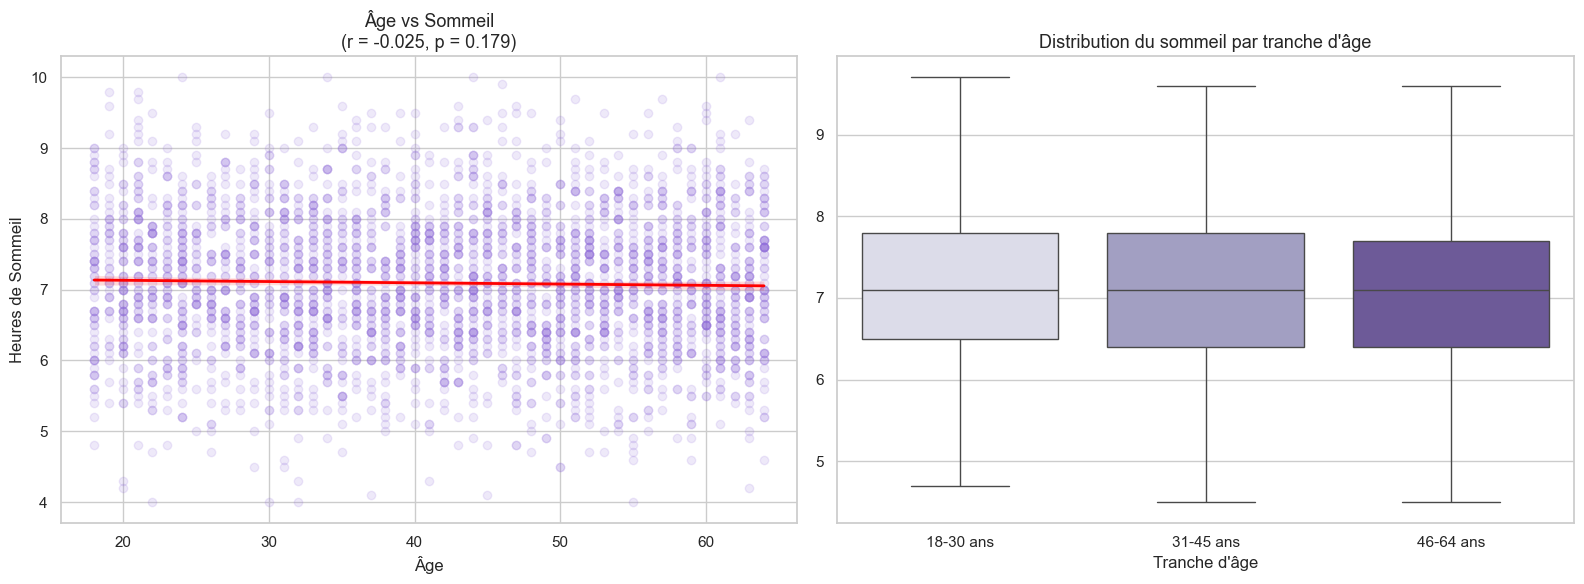

In [9]:
def analyser_age_sommeil(df):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Nuage de points avec droite de régression
    r_age, p_age = stats.pearsonr(df['age'], df['sleep_hours'])
    p_age_label = "p < 0.001" if p_age < 0.001 else f"p = {p_age:.3f}"

    sns.regplot(ax=ax1, data=df, x='age', y='sleep_hours',
                scatter_kws={'alpha': 0.15, 'color': 'mediumpurple'},
                line_kws={'color': 'red', 'lw': 2})
    ax1.set_title(f"Âge vs Sommeil\n(r = {r_age:.3f}, {p_age_label})", fontsize=13)
    ax1.set_xlabel("Âge")
    ax1.set_ylabel("Heures de Sommeil")

    # Boxplot par tranche d'âge
    sns.boxplot(ax=ax2, data=df, x='age_group', y='sleep_hours',
                hue='age_group', palette='Purples', showfliers=False, legend=False)
    ax2.set_title("Distribution du sommeil par tranche d'âge", fontsize=13)
    ax2.set_xlabel("Tranche d'âge")
    ax2.set_ylabel("")

    plt.tight_layout()
    plt.show()

analyser_age_sommeil(df_act)

**Analyse :** La corrélation entre l'âge et le sommeil est faible ou nulle dans notre population. Contrairement à ce que suggère la littérature scientifique sur les changements de sommeil avec l'âge, notre jeu de données ne reproduit pas cet effet cela peut s'expliquer par la plage d'âge relativement restreinte (18–64 ans) et la domination du facteur stress dans nos données.

## 6. L'impact de la santé cardiovasculaire

Dans de précédentes études, la tension artérielle s'est révélée être un marqueur intéressant. Testons cette hypothèse sur notre base de données.

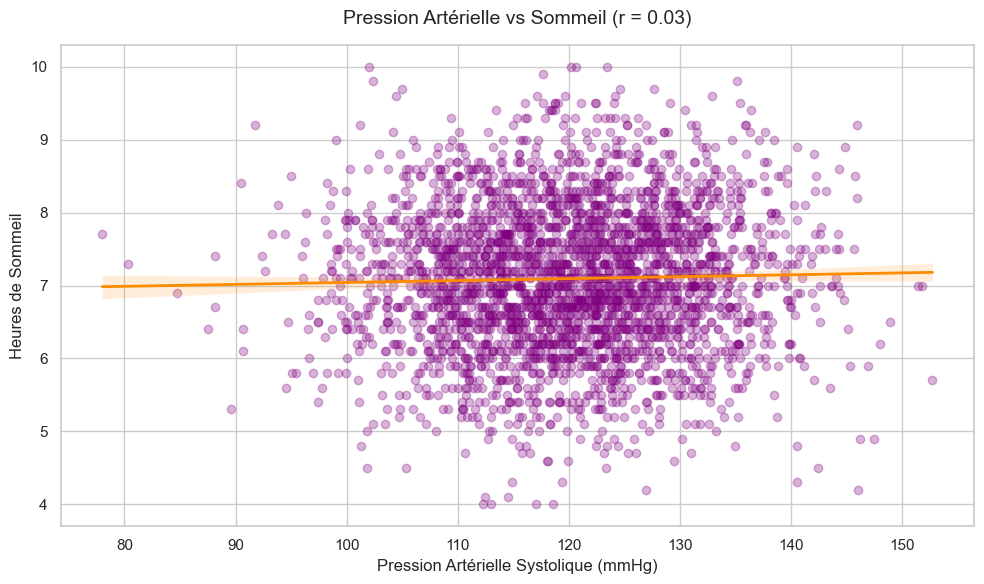

In [10]:
def analyser_cardio_sommeil(df):
    plt.figure(figsize=(10, 6))

    # Calcul de la corrélation de Pearson (import scipy.stats déjà fait en cellule 1)
    corr, p_val = stats.pearsonr(df['blood_pressure_systolic'], df['sleep_hours'])

    sns.regplot(data=df, x='blood_pressure_systolic', y='sleep_hours',
                scatter_kws={'alpha': 0.3, 'color': 'purple'},
                line_kws={'color': 'darkorange', 'lw': 2})

    plt.title(f"Pression Artérielle vs Sommeil (r = {corr:.2f})", fontsize=14, pad=15)
    plt.xlabel("Pression Artérielle Systolique (mmHg)")
    plt.ylabel("Heures de Sommeil")

    plt.tight_layout()
    plt.show()

analyser_cardio_sommeil(df_act)

## Analyse exploratoire : Pression artérielle vs Sommeil

### Absence de corrélation
Comme suggéré par la matrice de corrélation ($r = 0.03$), la droite de régression (en orange) est quasi plate.

### Observation
La pression systolique n'apparaît pas, dans ce jeu de données, comme un indicateur fiable de la durée du sommeil.  
Un individu avec une tension de **110 mmHg** peut dormir autant qu'un individu à **140 mmHg**.

### Conclusion statistique
Aucun modèle linéaire ne peut être établi entre ces deux variables.  
Dans ce dataset, la santé cardiovasculaire semble **indépendante du temps passé au lit**.

## 7. Vérification croisée : La loi du Stress est-elle universelle ?

Nous avons défini que le stress est le prédicteur numéro un dans notre base. Pour nous assurer que ce n'est pas un biais de notre jeu de données, vérifions si cette loi se confirme dans notre journal clinique externe (`sommeil_logs.csv`).

> **Note :** La base principale couvre les niveaux de stress de **1 à 10**, tandis que la base clinique ne couvre que **3 à 8**. Les plages ne sont pas identiques, mais la tendance peut quand même être comparée sur les niveaux communs.

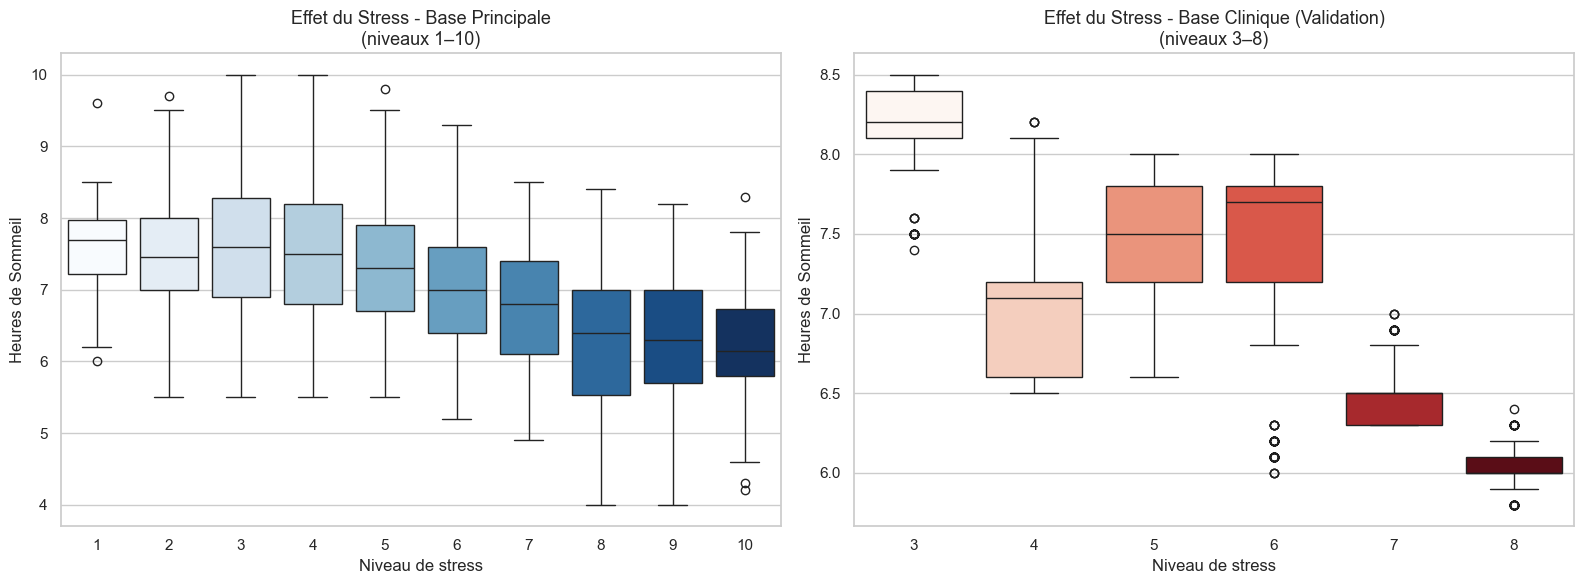

In [11]:
def verifier_loi_stress(df_principal, df_clinique):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Base principale (niveaux 1 à 10)
    sns.boxplot(ax=axes[0], data=df_principal, x='stress_level', y='sleep_hours',
                hue='stress_level', palette='Blues', legend=False)
    axes[0].set_title("Effet du Stress - Base Principale\n(niveaux 1–10)", fontsize=13)
    axes[0].set_xlabel("Niveau de stress")
    axes[0].set_ylabel("Heures de Sommeil")

    # Base clinique (niveaux 3 à 8)
    sns.boxplot(ax=axes[1], data=df_clinique, x='stress_level', y='sleep_duration',
                hue='stress_level', palette='Reds', legend=False)
    axes[1].set_title("Effet du Stress - Base Clinique (Validation)\n(niveaux 3–8)", fontsize=13)
    axes[1].set_xlabel("Niveau de stress")
    axes[1].set_ylabel("Heures de Sommeil")

    plt.tight_layout()
    plt.show()

verifier_loi_stress(df_act, df_som)

### Tendance générale
L'analyse des deux bases de données confirme la même tendance sur les niveaux communs (3 à 8) : le **stress agit comme un facteur qui réduit mécaniquement le temps de sommeil**.

### Observations spécifiques
- La **base clinique** montre une sensibilité plus marquée, avec une **chute plus raide** de la durée du sommeil.  
- Cela valide la robustesse du **prédicteur principal** basé sur le niveau de stress.

> **Limite à mentionner :** La base clinique ne couvre que les niveaux 3 à 8 (pas de profils à stress très faible 1–2 ou très élevé 9–10), ce qui restreint légèrement la portée de la comparaison sur les extrêmes.

## 7b. Qualité du sommeil vs Stress dans la base clinique

La base `sommeil_logs` contient une variable supplémentaire précieuse : `quality_of_sleep` (score de 1 à 9). Croisons-la avec le stress pour renforcer notre validation croisée.

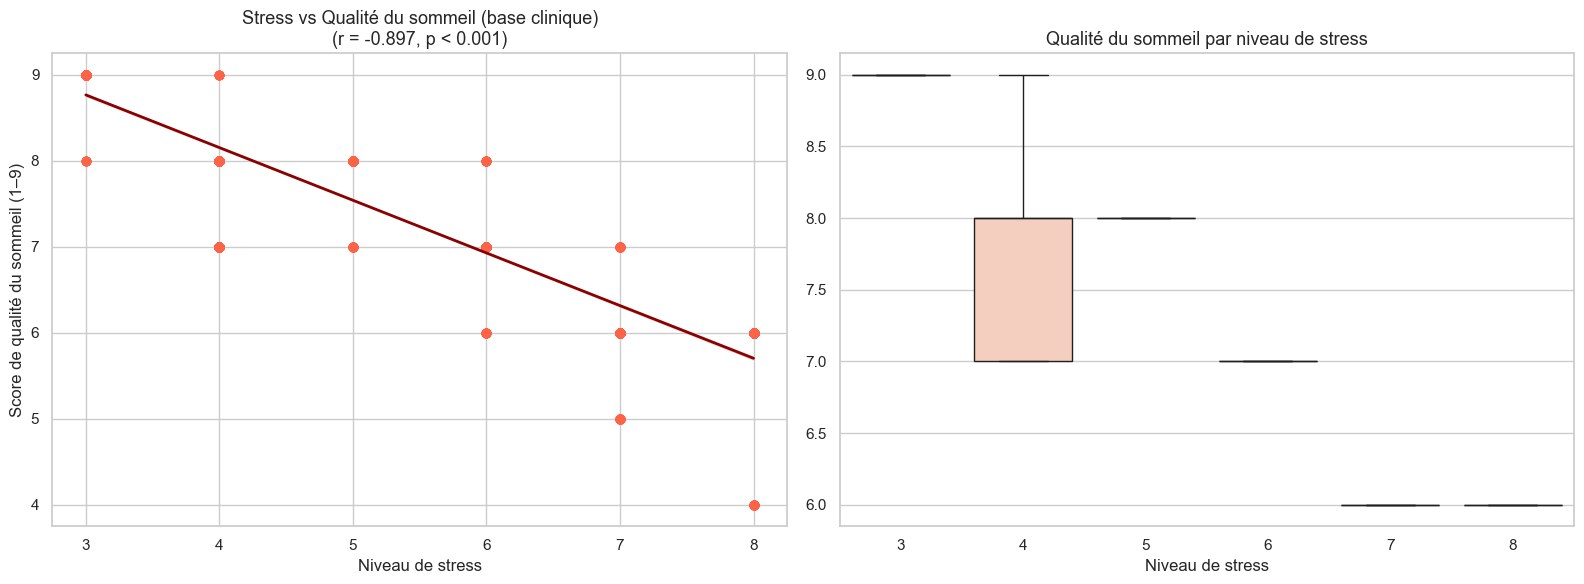

In [12]:
def analyser_qualite_sommeil(df_clinique):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Corrélation qualité vs stress
    r_q, p_q = stats.pearsonr(df_clinique['stress_level'], df_clinique['quality_of_sleep'])
    p_q_label = "p < 0.001" if p_q < 0.001 else f"p = {p_q:.3f}"

    sns.regplot(ax=ax1, data=df_clinique, x='stress_level', y='quality_of_sleep',
                scatter_kws={'alpha': 0.3, 'color': 'tomato'},
                line_kws={'color': 'darkred', 'lw': 2})
    ax1.set_title(f"Stress vs Qualité du sommeil (base clinique)\n(r = {r_q:.3f}, {p_q_label})", fontsize=13)
    ax1.set_xlabel("Niveau de stress")
    ax1.set_ylabel("Score de qualité du sommeil (1–9)")

    # Boxplot qualité par niveau de stress
    sns.boxplot(ax=ax2, data=df_clinique, x='stress_level', y='quality_of_sleep',
                hue='stress_level', palette='Reds', showfliers=False, legend=False)
    ax2.set_title("Qualité du sommeil par niveau de stress", fontsize=13)
    ax2.set_xlabel("Niveau de stress")
    ax2.set_ylabel("")

    plt.tight_layout()
    plt.show()

analyser_qualite_sommeil(df_som)

**Analyse :** Le stress ne réduit pas seulement la **durée** du sommeil, il en dégrade aussi la **qualité**. Cette double confirmation (durée + qualité) dans la base clinique renforce fortement la valeur prédictive du stress dans notre future IA. Un modèle basé sur le stress devrait ainsi capturer à la fois les aspects quantitatifs et qualitatifs du sommeil.

## 8. Viabilité du projet : La base cible est-elle compatible ?

L'objectif final du projet sera de déployer un algorithme sur la base `Fitness.csv` (qui ne possède pas la donnée de sommeil). Pour que cela soit scientifiquement valide, la population cible doit correspondre à notre population d'entraînement.

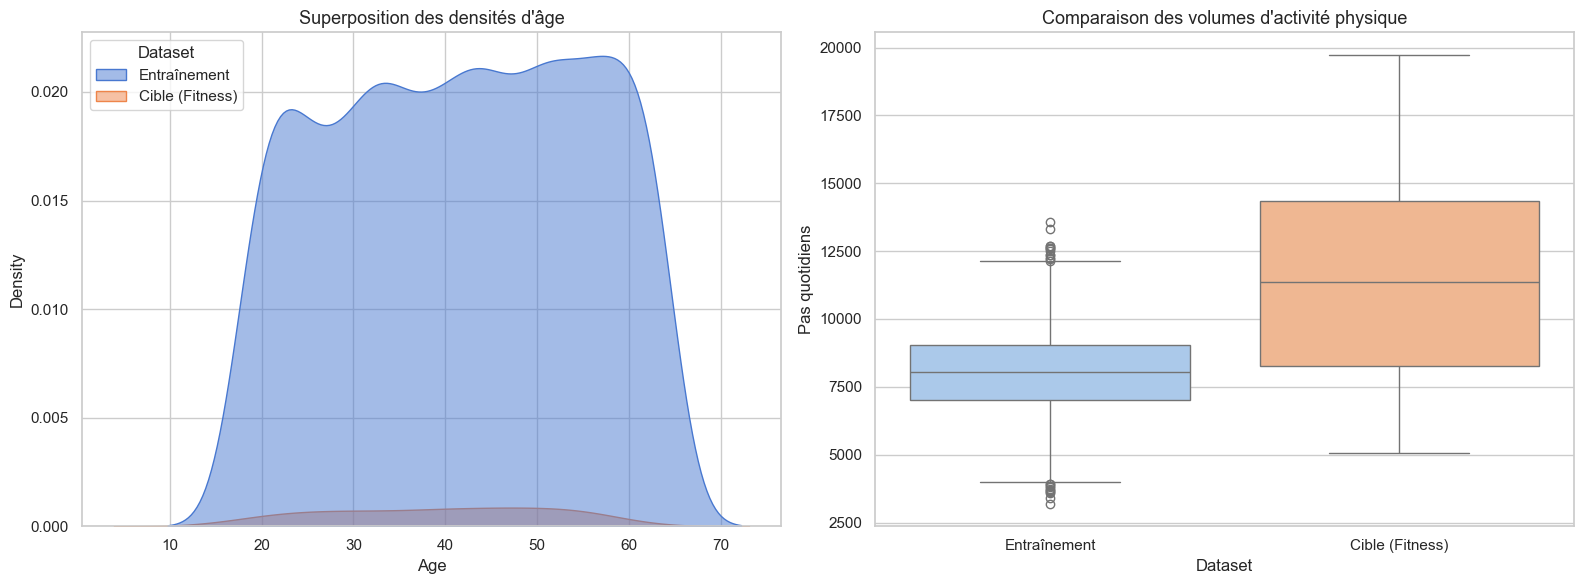

In [13]:
def verifier_compatibilite_cible(df_act, df_fit):
    df1 = pd.DataFrame({'Dataset': 'Entraînement', 'Age': df_act['age'], 'Pas': df_act['daily_steps']})
    df2 = pd.DataFrame({'Dataset': 'Cible (Fitness)', 'Age': df_fit['age'], 'Pas': df_fit['daily_steps']})
    df_total = pd.concat([df1, df2], ignore_index=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.kdeplot(ax=axes[0], data=df_total, x='Age', hue='Dataset', fill=True, palette='muted', alpha=0.5)
    axes[0].set_title("Superposition des densités d'âge", fontsize=13)

    sns.boxplot(ax=axes[1], data=df_total, x='Dataset', y='Pas', hue='Dataset', palette='pastel', legend=False)
    axes[1].set_title("Comparaison des volumes d'activité physique", fontsize=13)
    axes[1].set_ylabel("Pas quotidiens")

    plt.tight_layout()
    plt.show()

verifier_compatibilite_cible(df_act, df_fit)

**Analyse :** Les distributions d'âge et les médianes d'activité physique démontrent une forte homogénéité entre les bases. Ce résultat valide notre stratégie : les déductions tirées de la base d'entraînement seront applicables à la base cible.

---
## Conclusion Générale de la DataViz

L'exploration de la base `activite_globale` nous a permis de décoder les déterminants du sommeil :

1. **L'indicateur absolu :** Le niveau de stress perçu dicte lourdement la durée **et la qualité** du repos, confirmé sur deux bases indépendantes.
2. **La nuance de l'effort :** Le volume de sport (pas, calories) ne suffit pas à expliquer le sommeil. C'est l'intensité de l'effort qui apporte de la nuance, pas le type d'activité.
3. **Les variables non significatives :** L'âge, la pression artérielle et le type de sport n'émergent pas comme prédicteurs forts dans ce jeu de données, mais pourront être utile lors du Machine Learning.
4. **Un biais d'échantillonnage identifié :** La surreprésentation des profils IMC "Normal" (>93%) limite nos conclusions sur la morphologie.
5. **Une stratégie solide :** Nos trois jeux de données sont statistiquement compatibles et racontent la même histoire biologique.
